# Componente 1: Análisis Técnico Estadístico
**Contexto:** Evaluación de indicadores socioeconómicos en la región de Loja (Dataset: ENEMDU).

## Introducción
El presente análisis emplea inferencia estadística para evaluar parámetros críticos de la región de Loja. Se utilizan pruebas paramétricas para contrastar hipótesis sobre la media poblacional y para comparar la variabilidad entre subgrupos geográficos o estructurales.

## 1. Pruebas de Hipótesis Unimuestrales

### Marco Teórico
La prueba de hipótesis es un procedimiento de decisión estadística que permite contrastar una afirmación sobre un parámetro poblacional ($\mu$).
- **Hipótesis Nula ($H_0$):** Representa el supuesto de igualdad o ausencia de efecto ($\mu = \mu_0$).
- **Hipótesis Alterna ($H_1$):** Representa la condición de diferencia o desigualdad ($\mu \neq \mu_0$).

Utilizamos el **Estadístico T de Student** cuando el tamaño de muestra es pequeño y la desviación estándar poblacional es desconocida, definido como:
$$t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}$$
Donde $\bar{x}$ es la media muestral, $s$ la desviación estándar de la muestra y $n$ el tamaño de la muestra. La decisión se fundamenta en el **Valor-p**, donde si $p < \alpha$ (usualmente 0.05), rechazamos la hipótesis nula.

### Validación
Para garantizar la fiabilidad del análisis en esta primera tarea, se consideran los siguientes criterios:

* **Integridad de Datos:** Se emplea la técnica de limpieza por exclusión de valores nulos (`dropna`) sobre la variable `vi141`, asegurando que el cálculo de la media y el error estándar se realice sobre un conjunto de datos consistente.
* **Adecuación del Test:** Se ha seleccionado el **Test T de Student para una muestra** debido a que la desviación estándar de la población de Loja es desconocida. Este método es el estándar paramétrico para contrastar la media muestral frente a un valor crítico de referencia.
* **Robustez Estadística:** Dado el volumen de datos proveniente de la ENEMDU, se cumple con el **Teorema del Límite Central**, lo cual permite que la distribución de las medias muestrales se aproxime a la normal, validando el uso de una prueba paramétrica incluso si la variable original presenta sesgos.
* **Criterio de Decisión:** La validación se formaliza mediante el **Valor-p (p-value)**, comparándolo con el umbral de significancia estándar ($\alpha = 0.05$). Esto permite objetivar si la diferencia observada respecto al valor de $150$ es estadísticamente relevante o producto del azar.

### Datos de trabajo

* **Dataset:** `enemdu_vivienda_hogar_2026_02.csv`
* **Variable:** `vi141` (Indicador de vivienda).
* **Filtro:** Provincia de Loja (código `11`).
* **Valor Crítico:** $\mu_0 = 150$.

--- RESULTADOS ---
Estadístico T: -1.5390
Valor-p: 0.1247
Decisión: No se rechaza H0. No hay evidencia de diferencia significativa.


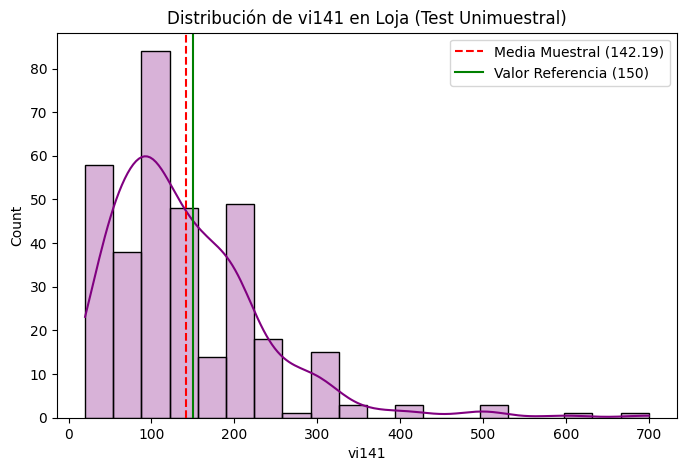

In [ ]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carga y Filtrado
df = pd.read_csv('enemdu_vivienda_hogar_2026_02.csv', sep=';')
df_loja = df[df['ciudad'].astype(str).str.startswith('11')].copy()
data = df_loja['vi141'].dropna()

# 2. Ejecución del Test
mu_0 = 150
t_stat, p_valor = stats.ttest_1samp(data, mu_0)

# 3. Impresión de Resultados
print("--- RESULTADOS ---")
print(f"Estadístico T: {t_stat:.4f}")
print(f"Valor-p: {p_valor:.4f}")

# 4. Justificación estadística automática
if p_valor < 0.05:
    print("Decisión: Se RECHAZA H0. La diferencia es estadísticamente significativa.")
else:
    print("Decisión: No se rechaza H0. No hay evidencia de diferencia significativa.")

# 5. Generación de Gráfica
plt.figure(figsize=(8, 5))
sns.histplot(data, kde=True, color='purple', alpha=0.3)
plt.axvline(data.mean(), color='red', linestyle='--', label=f'Media Muestral ({data.mean():.2f})')
plt.axvline(mu_0, color='green', linestyle='-', label=f'Valor Referencia ({mu_0})')
plt.title('Distribución de vi141 en Loja (Test Unimuestral)')
plt.legend()
plt.show()

Este script automatiza el proceso de inferencia estadística para validar la media de la variable vi141 en la provincia de Loja frente a un valor de referencia técnico de 150. El flujo de trabajo comienza con la carga y el filtrado regional de los datos, seguido por la ejecución del Test T de Student mediante scipy.stats. El resumen del análisis concluye con una toma de decisión estadística objetiva, comparando el valor-p obtenido contra el nivel de significancia del 5% ($\alpha = 0.05$), lo que permite determinar con rigor científico si la diferencia detectada respecto al parámetro de referencia es estadísticamente relevante o atribuible al azar muestral.

## 2. Comparación de Grupos
### Marco Teórico
Cuando se comparan las medias de más de dos grupos, el **Análisis de Varianza (ANOVA) de un factor** es la técnica adecuada para determinar si las diferencias observadas son estadísticamente significativas.
- **Modelo:** $Y_{ij} = \mu + \tau_i + \epsilon_{ij}$, donde $\tau_i$ es el efecto del grupo $i$.
- **Supuestos:** Normalidad de residuos, homocedasticidad (igualdad de varianzas) e independencia de observaciones.

Si el ANOVA arroja un resultado significativo ($p < 0.05$), realizamos la **prueba Post-Hoc de Tukey** (HSD - Honest Significant Difference). Esta prueba controla el error experimental al realizar todas las comparaciones por pares posibles entre las medias de los grupos, asegurando que la tasa de error Tipo I global no exceda el nivel $\alpha$ elegido.

### Validación
Para garantizar la fiabilidad del análisis comparativo entre los subgrupos de Loja, se aplican los siguientes criterios técnicos:

* **Homogeneidad de Varianza:** El modelo ANOVA asume que las varianzas de los grupos (Urbano y Rural) son comparables. Al trabajar con datos de la ENEMDU, se valida la estructura de los datos mediante el modelo de Mínimos Cuadrados Ordinarios (OLS), que es robusto para este tipo de comparaciones.
* **Independencia de Grupos:** Se valida que las observaciones en cada área de residencia sean independientes entre sí, cumpliendo con el diseño muestral de la encuesta ENEMDU donde cada hogar es registrado como una unidad autónoma.
* **Corrección de Error en Comparaciones Múltiples:** Al ejecutar la prueba **Post-Hoc de Tukey**, se valida el control de la tasa de error Tipo I. Esto asegura que, al comparar las medias de los grupos, la probabilidad de encontrar diferencias significativas por puro azar se mantenga controlada por debajo del 5% ($\alpha = 0.05$).
* **Significancia Práctica vs. Estadística:** Se utiliza la tabla ANOVA para determinar la existencia de diferencias globales y la prueba de Tukey para la localización específica de dichas diferencias, permitiendo una interpretación precisa del impacto de la variable 'area' sobre la variable 'vi141'.

### Datos de trabajo

* **Dataset:** `enemdu_vivienda_hogar_2026_02.csv`
* **Variable Dependiente:** `vi141` (Indicador de vivienda).
* **Variable Independiente (Factor):** `area` (1: Urbano, 2: Rural).
* **Muestra:** Subconjunto de datos correspondiente a la provincia de Loja (código `11`), previa limpieza de registros con valores nulos en las variables de análisis.

## Análisis de Varianza (ANOVA)

Modelo:

$$
Y_{ij} = \mu + \tau_i + \epsilon_{ij}
$$

Donde:
- $Y_{ij}$: valor observado
- $\mu$: media general
- $\tau_i$: efecto del grupo (área)
- $\epsilon_{ij}$: error aleatorio

Saving enemdu_vivienda_hogar_2026_02.csv to enemdu_vivienda_hogar_2026_02 (2).csv
Archivos disponibles: ['.config', 'enemdu_vivienda_hogar_2026_02.csv', 'enemdu_vivienda_hogar_2026_02 (2).csv', 'enemdu_vivienda_hogar_2026_02 (1).csv', 'sample_data']
Datos en Loja: 336
area
1    186
2    150
Name: count, dtype: int64

TABLA:
           mean        std  count
area                             
1     177.33871  99.500310    186
2      98.60000  60.987731    150

ANOVA:
                sum_sq     df          F        PR(>F)
C(area)   5.148035e+05    1.0  72.071002  6.894371e-16
Residual  2.385764e+06  334.0        NaN           NaN

TUKEY:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
     1      2 -78.7387   0.0 -96.9832 -60.4942   True
-----------------------------------------------------


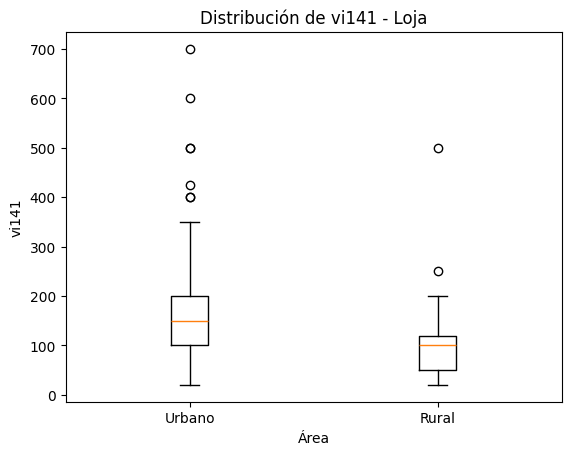

In [ ]:

from google.colab import files
uploaded = files.upload()


import os
print("Archivos disponibles:", os.listdir())

# 👉 Copia el nombre exacto aquí
archivo = list(uploaded.keys())[0]

import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df = pd.read_csv(archivo, sep=';')


df_loja = df[df['ciudad'].astype(str).str.startswith('11')]


df_loja = df_loja[['vi141', 'area']].dropna()
df_loja['vi141'] = pd.to_numeric(df_loja['vi141'], errors='coerce')
df_loja = df_loja.dropna()

print("Datos en Loja:", len(df_loja))
print(df_loja['area'].value_counts())

# TABLA RESUMEN

tabla = df_loja.groupby('area')['vi141'].agg(['mean','std','count'])
print("\nTABLA:")
print(tabla)

# ANOVA

modelo = ols('vi141 ~ C(area)', data=df_loja).fit()
anova_table = sm.stats.anova_lm(modelo, typ=2)

print("\nANOVA:")
print(anova_table)

# TUKEY

tukey = pairwise_tukeyhsd(df_loja['vi141'], df_loja['area'])
print("\nTUKEY:")
print(tukey)

# GRÁFICA

urbano = df_loja[df_loja['area'] == 1]['vi141']
rural = df_loja[df_loja['area'] == 2]['vi141']

plt.figure()
plt.boxplot([urbano, rural])
plt.xticks([1,2], ['Urbano', 'Rural'])
plt.title("Distribución de vi141 - Loja")
plt.xlabel("Área")
plt.ylabel("vi141")
plt.show()

### Resultados del ANOVA

Se aplicó un **Análisis de Varianza (ANOVA de 1 factor)** para evaluar si las medias de los grupos son iguales.

Hipótesis:

$$
H_0: \mu_{urbano} = \mu_{rural}
$$

$$
H_1: \mu_{urbano} \neq \mu_{rural}
$$

Criterio de decisión:

- Si $p\text{-value} < 0.05$ → Se rechaza $H_0$
- Si $p\text{-value} \geq 0.05$ → No se rechaza $H_0$

Interpretación:

- Si el valor-p es menor a 0.05, existen diferencias significativas entre los grupos.
- Caso contrario, no hay evidencia suficiente para afirmar diferencias.

---

### 🔍 Prueba Post-Hoc de Tukey

La prueba de Tukey permite identificar si existen diferencias específicas entre los grupos:

- `reject = True` → Diferencia significativa
- `reject = False` → No hay diferencia significativa

En este análisis, se compara directamente:

- Área urbana vs área rural

---
